# Chapter 10: Putting It All Together — A Unified Multimodal Model

*Build a Multimodal Model from Scratch · Chapter 10 of 10*

> **This chapter in context:** This is the capstone. We assemble the ViT encoder (Ch01), AudioEncoder (Ch08), ProjectionMLP bridge (Ch03), hybrid attention mask (Ch03), two-stage training (Ch04), and GPT decoder (Ch03) into a single model that reads both an image and a sound clip, then generates a natural-language description. Every architectural decision in the previous chapters has been building to this assembly.

In [1]:
%matplotlib inline
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
from torch.utils.data import Dataset, DataLoader
import math, uuid

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PAL = dict(bg='#F8F9FA', dark='#2C3E50', blue='#4A90D9', orange='#E67E22',
           green='#27AE60', red='#E74C3C', purple='#8E44AD', grey='#95A5A6')
print(f"Device: {DEVICE}")

Device: cpu


## Problem 1 — Three Modalities, One Model

By the end of Ch01–09, we have three separate encoders:
- **ViT** (Ch01): turns an image into 64 patch tokens
- **AudioEncoder** (Ch08): turns a mel spectrogram into 16 audio tokens
- **GPT** (Ch03): generates text tokens auto-regressively

Each encoder was trained in isolation. The question for this chapter:

> **Can we wire them together so that a single GPT decoder generates a description conditioned on both the image and the audio?**

The answer is yes, and the wiring diagram is almost identical to Ch03's VLM — we just have *two* visual prefixes instead of one.

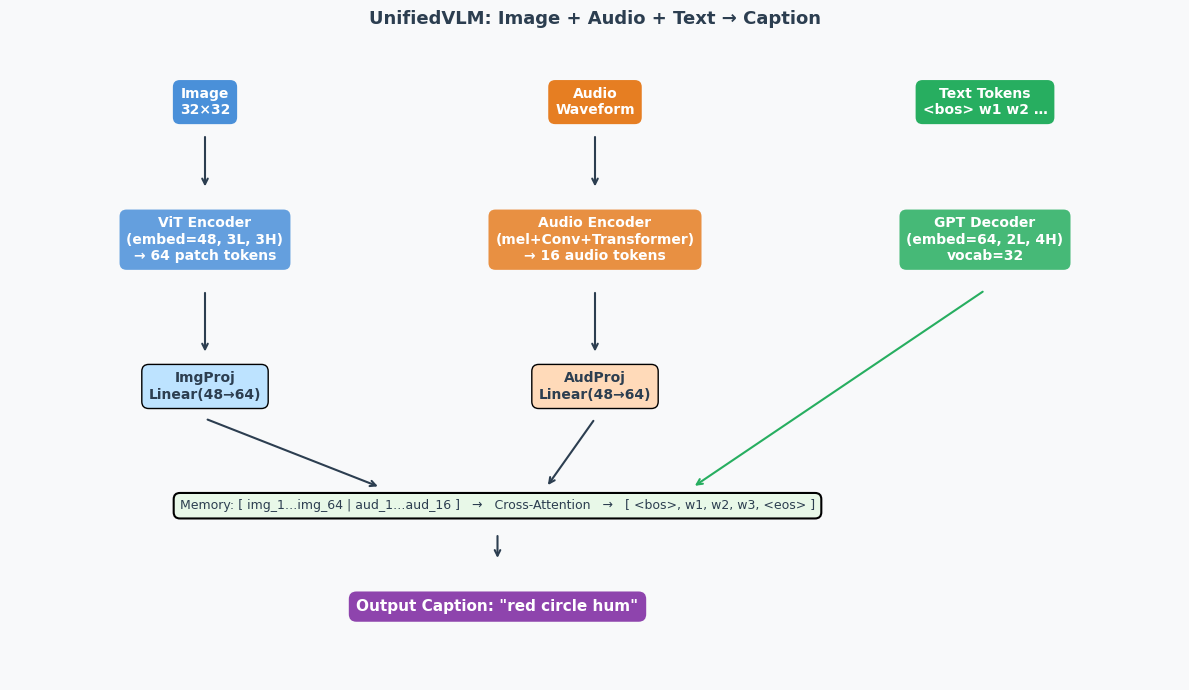

In [2]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 12); ax.set_ylim(0, 7)
ax.axis('off')
ax.set_facecolor(PAL['bg'])
fig.patch.set_facecolor(PAL['bg'])

box_kw = dict(ha='center', va='center', fontsize=10, fontweight='bold',
              bbox=dict(boxstyle='round,pad=0.5', lw=1.5))

# Input boxes (row 1)
ax.text(2, 6.3, 'Image\n32×32', color='white', **{**box_kw, 'bbox': dict(boxstyle='round,pad=0.5', facecolor=PAL['blue'], lw=0)})
ax.text(6, 6.3, 'Audio\nWaveform', color='white', **{**box_kw, 'bbox': dict(boxstyle='round,pad=0.5', facecolor=PAL['orange'], lw=0)})
ax.text(10, 6.3, 'Text Tokens\n<bos> w1 w2 …', color='white', **{**box_kw, 'bbox': dict(boxstyle='round,pad=0.5', facecolor=PAL['green'], lw=0)})

# Encoder boxes (row 2)
ax.text(2, 4.8, 'ViT Encoder\n(embed=48, 3L, 3H)\n→ 64 patch tokens', color='white', **{**box_kw, 'bbox': dict(boxstyle='round,pad=0.5', facecolor=PAL['blue'], lw=0, alpha=0.85)})
ax.text(6, 4.8, 'Audio Encoder\n(mel+Conv+Transformer)\n→ 16 audio tokens', color='white', **{**box_kw, 'bbox': dict(boxstyle='round,pad=0.5', facecolor=PAL['orange'], lw=0, alpha=0.85)})
ax.text(10, 4.8, 'GPT Decoder\n(embed=64, 2L, 4H)\nvocab=32', color='white', **{**box_kw, 'bbox': dict(boxstyle='round,pad=0.5', facecolor=PAL['green'], lw=0, alpha=0.85)})

# Projection boxes (row 3)
ax.text(2, 3.2, 'ImgProj\nLinear(48→64)', color=PAL['dark'], **{**box_kw, 'bbox': dict(boxstyle='round,pad=0.5', facecolor='#BDE3FF', lw=1)})
ax.text(6, 3.2, 'AudProj\nLinear(48→64)', color=PAL['dark'], **{**box_kw, 'bbox': dict(boxstyle='round,pad=0.5', facecolor='#FFDAB9', lw=1)})

# Token sequence box
ax.text(5, 1.9,
    'Memory: [ img_1…img_64 | aud_1…aud_16 ]   →   Cross-Attention   →   [ <bos>, w1, w2, w3, <eos> ]',
    color=PAL['dark'], ha='center', va='center', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#E8F8E8', lw=1.5))

# Output
ax.text(5, 0.8, 'Output Caption: "red circle hum"', color='white',
    ha='center', va='center', fontsize=11, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.5', facecolor=PAL['purple'], lw=0))

# Arrows
arw = dict(arrowstyle='->', color=PAL['dark'], lw=1.5)
ax.annotate('', xy=(2, 5.35), xytext=(2, 5.95), arrowprops=arw)
ax.annotate('', xy=(6, 5.35), xytext=(6, 5.95), arrowprops=arw)
ax.annotate('', xy=(2, 3.55), xytext=(2, 4.25), arrowprops=arw)
ax.annotate('', xy=(6, 3.55), xytext=(6, 4.25), arrowprops=arw)
ax.annotate('', xy=(3.8, 2.1), xytext=(2, 2.85), arrowprops=arw)
ax.annotate('', xy=(5.5, 2.1), xytext=(6, 2.85), arrowprops=arw)
ax.annotate('', xy=(7, 2.1), xytext=(10, 4.25), arrowprops=dict(arrowstyle='->', color=PAL['green'], lw=1.5))
ax.annotate('', xy=(5, 1.3), xytext=(5, 1.6), arrowprops=arw)

ax.set_title('UnifiedVLM: Image + Audio + Text → Caption', fontsize=13, fontweight='bold',
             color=PAL['dark'], pad=10)
plt.tight_layout()
plt.show()

## Problem 2 — Building the Dataset

We need a dataset where image content, audio content, and caption are all aligned. Real multimodal datasets (LAION, WavCaps) are hundreds of gigabytes. For this chapter, we build four synthetic scenes — small enough to train on CPU in minutes, but rich enough to test all three modalities:

| Scene | Image | Audio | Caption |
|---|---|---|---|
| 0 | Red circle | 200 Hz sine | "red circle hum" |
| 1 | Blue square | 1000 Hz sine | "blue square beep" |
| 2 | Green triangle | White noise | "green triangle noise" |
| 3 | Yellow star | 200+400 Hz chord | "yellow star chord" |

Each scene generates **50 samples** with slight Gaussian noise added to images and audio, giving 200 training samples total.

In [3]:
def make_circle_image(size=32, color=(1,0,0), noise=0.05):
    img = np.zeros((size, size, 3))
    cx, cy, r = size//2, size//2, size//4
    for i in range(size):
        for j in range(size):
            if (i-cx)**2 + (j-cy)**2 < r**2:
                img[i,j] = color
    img += np.random.randn(*img.shape) * noise
    return np.clip(img, 0, 1).astype(np.float32)

def make_square_image(size=32, color=(0,0,1), noise=0.05):
    img = np.zeros((size, size, 3))
    s = size//4
    img[s:3*s, s:3*s] = color
    img += np.random.randn(*img.shape) * noise
    return np.clip(img, 0, 1).astype(np.float32)

def make_triangle_image(size=32, color=(0,0.7,0), noise=0.05):
    img = np.zeros((size, size, 3))
    for i in range(size//4, 3*size//4):
        width = int((i - size//4) / (size//2) * size//2)
        c = size//2
        img[i, max(0,c-width):min(size,c+width)] = color
    img += np.random.randn(*img.shape) * noise
    return np.clip(img, 0, 1).astype(np.float32)

def make_star_image(size=32, color=(1,0.8,0), noise=0.05):
    img = np.zeros((size, size, 3))
    cx, cy = size//2, size//2
    for i in range(size):
        for j in range(size):
            dx, dy = abs(i-cx), abs(j-cy)
            if dx + dy < size//4:
                img[i,j] = color
    img += np.random.randn(*img.shape) * noise
    return np.clip(img, 0, 1).astype(np.float32)

def make_sine_wave(freq=200, sr=8000, duration=0.5, noise=0.05):
    t = np.linspace(0, duration, int(sr*duration))
    wav = np.sin(2*np.pi*freq*t).astype(np.float32)
    wav += np.random.randn(*wav.shape).astype(np.float32) * noise
    return wav

def make_noise_burst(sr=8000, duration=0.5):
    return (np.random.randn(int(sr*duration)) * 0.5).astype(np.float32)

def make_chord(freqs=(200,400), sr=8000, duration=0.5, noise=0.05):
    t = np.linspace(0, duration, int(sr*duration))
    wav = sum(np.sin(2*np.pi*f*t) for f in freqs).astype(np.float32) / len(freqs)
    wav += np.random.randn(*wav.shape).astype(np.float32) * noise
    return wav

print("Image generation functions defined.")
print("Audio generation functions defined.")
# Quick sanity check
sample_img = make_circle_image()
sample_wav = make_sine_wave(200)
print(f"Sample image shape: {sample_img.shape}, range: [{sample_img.min():.2f}, {sample_img.max():.2f}]")
print(f"Sample audio shape: {sample_wav.shape}, range: [{sample_wav.min():.2f}, {sample_wav.max():.2f}]")

Image generation functions defined.
Audio generation functions defined.
Sample image shape: (32, 32, 3), range: [0.00, 1.00]
Sample audio shape: (4000,), range: [-1.13, 1.13]


In [4]:
def mel_filterbank(n_mels=32, n_fft=256, sr=8000, fmin=0, fmax=None):
    if fmax is None: fmax = sr // 2
    def hz_to_mel(f): return 2595 * np.log10(1 + f/700)
    def mel_to_hz(m): return 700 * (10**(m/2595) - 1)
    mel_min, mel_max = hz_to_mel(fmin), hz_to_mel(fmax)
    mel_pts = np.linspace(mel_min, mel_max, n_mels + 2)
    hz_pts = mel_to_hz(mel_pts)
    bin_pts = np.floor((n_fft + 1) * hz_pts / sr).astype(int)
    fbank = np.zeros((n_mels, n_fft // 2 + 1))
    for m in range(1, n_mels + 1):
        lo, ctr, hi = bin_pts[m-1], bin_pts[m], bin_pts[m+1]
        for k in range(lo, ctr):
            if ctr != lo: fbank[m-1, k] = (k - lo) / (ctr - lo)
        for k in range(ctr, hi):
            if hi != ctr: fbank[m-1, k] = (hi - k) / (hi - ctr)
    return fbank.astype(np.float32)

MEL_FB = mel_filterbank(n_mels=32, n_fft=256, sr=8000)

def wav_to_mel(wav, n_fft=256, hop=128, n_mels=32):
    frames = []
    for i in range(0, len(wav) - n_fft + 1, hop):
        frame = wav[i:i+n_fft] * np.hanning(n_fft).astype(np.float32)
        spec = np.abs(np.fft.rfft(frame))**2
        frames.append(spec)
    S = np.array(frames).T   # (n_fft//2+1, T)
    mel = MEL_FB @ S          # (n_mels, T)
    return np.log(mel + 1e-6).astype(np.float32)  # (n_mels, T)

# Sanity check
test_mel = wav_to_mel(sample_wav)
print(f"Mel filterbank shape: {MEL_FB.shape}")
print(f"Mel spectrogram shape: {test_mel.shape}  (n_mels × time_frames)")

Mel filterbank shape: (32, 129)
Mel spectrogram shape: (32, 30)  (n_mels × time_frames)


In [5]:
VOCAB = ["<pad>", "<bos>", "<eos>",
         "red", "circle", "hum", "blue", "square", "beep",
         "green", "triangle", "noise", "yellow", "star", "chord"]
# Pad to 32 tokens
while len(VOCAB) < 32: VOCAB.append(f"<unused{len(VOCAB)}>")
w2i = {w:i for i,w in enumerate(VOCAB)}
i2w = {i:w for i,w in enumerate(VOCAB)}

CAPTIONS = [
    ["<bos>", "red", "circle", "hum", "<eos>"],
    ["<bos>", "blue", "square", "beep", "<eos>"],
    ["<bos>", "green", "triangle", "noise", "<eos>"],
    ["<bos>", "yellow", "star", "chord", "<eos>"],
]

class MultimodalDataset(Dataset):
    def __init__(self, n_per_class=50):
        self.samples = []
        image_fns = [
            lambda: make_circle_image(),
            lambda: make_square_image(),
            lambda: make_triangle_image(),
            lambda: make_star_image(),
        ]
        audio_fns = [
            lambda: make_sine_wave(200),
            lambda: make_sine_wave(1000),
            lambda: make_noise_burst(),
            lambda: make_chord((200,400)),
        ]
        for cls in range(4):
            for _ in range(n_per_class):
                img = torch.from_numpy(image_fns[cls]()).permute(2,0,1)  # (3,32,32)
                wav = audio_fns[cls]()
                mel = torch.from_numpy(wav_to_mel(wav))  # (32, T)
                cap = [w2i[w] for w in CAPTIONS[cls]]
                self.samples.append((img, mel, cap))
    def __len__(self): return len(self.samples)
    def __getitem__(self, i): return self.samples[i]

def collate_fn(batch):
    imgs, mels, caps = zip(*batch)
    imgs = torch.stack(imgs)
    # Pad mels to same T
    max_t = max(m.shape[1] for m in mels)
    mels_pad = torch.zeros(len(mels), 32, max_t)
    for i, m in enumerate(mels): mels_pad[i, :, :m.shape[1]] = m
    # Pad captions
    max_c = max(len(c) for c in caps)
    caps_pad = torch.full((len(caps), max_c), w2i["<pad>"], dtype=torch.long)
    for i, c in enumerate(caps): caps_pad[i, :len(c)] = torch.tensor(c)
    return imgs, mels_pad, caps_pad

dataset = MultimodalDataset(n_per_class=50)
loader = DataLoader(dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
print(f"Dataset: {len(dataset)} samples, {len(loader)} batches")
print(f"Vocabulary size: {len(VOCAB)} tokens")
print(f"Sample caption tokens: {CAPTIONS[0]} → {[w2i[w] for w in CAPTIONS[0]]}")

Dataset: 200 samples, 13 batches
Vocabulary size: 32 tokens
Sample caption tokens: ['<bos>', 'red', 'circle', 'hum', '<eos>'] → [1, 3, 4, 5, 2]


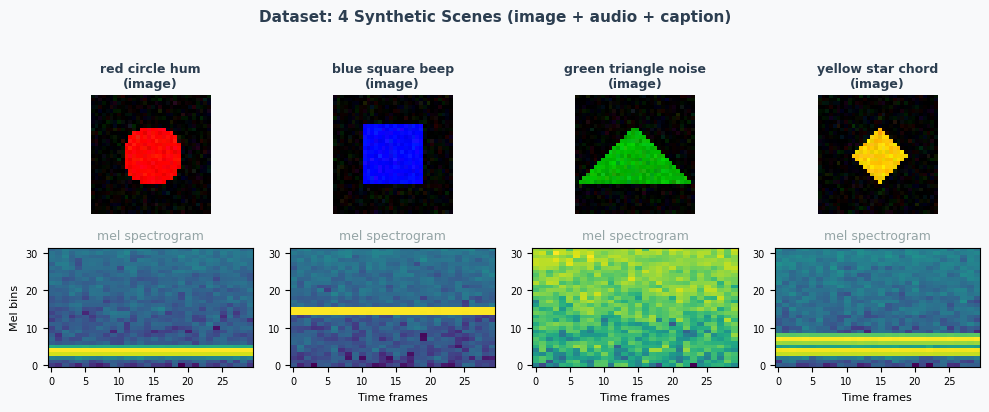

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(10, 4))
fig.patch.set_facecolor(PAL['bg'])

titles = ["red circle hum", "blue square beep", "green triangle noise", "yellow star chord"]
colors = [PAL['red'], PAL['blue'], PAL['green'], PAL['orange']]

for cls in range(4):
    img, mel, cap = dataset[cls * 50]
    # Top row: images
    ax_img = axes[0, cls]
    ax_img.imshow(img.permute(1, 2, 0).numpy().clip(0, 1))
    ax_img.set_title(titles[cls], fontsize=9, fontweight='bold', color=PAL['dark'])
    ax_img.axis('off')
    # Bottom row: mel spectrograms
    ax_mel = axes[1, cls]
    im = ax_mel.imshow(mel.numpy(), aspect='auto', origin='lower', cmap='viridis')
    ax_mel.set_xlabel('Time frames', fontsize=8)
    if cls == 0: ax_mel.set_ylabel('Mel bins', fontsize=8)
    ax_mel.tick_params(labelsize=7)

axes[0, 0].set_title('red circle hum\n(image)', fontsize=9, fontweight='bold', color=PAL['dark'])
for cls in range(4):
    axes[0, cls].set_title(f'{titles[cls]}\n(image)', fontsize=9, fontweight='bold', color=PAL['dark'])
    axes[1, cls].set_title(f'mel spectrogram', fontsize=9, color=PAL['grey'])

plt.suptitle('Dataset: 4 Synthetic Scenes (image + audio + caption)', fontsize=11,
             fontweight='bold', color=PAL['dark'], y=1.02)
plt.tight_layout()
plt.show()

## Problem 3 — The Three Encoders

We build three compact encoders, each with ~50K–150K parameters:

- **ViTEncoder**: PatchEmbed (Conv2d) + positional embedding + 3-layer Transformer. Input: `(B, 3, 32, 32)` → Output: `(B, 64, 48)` (64 patch tokens, embed_dim=48). The CLS token is computed but discarded — we use all patch tokens as visual context.

- **AudioEncoder**: Conv1d projects mel bins → 48-dim features, AdaptiveAvgPool1d compresses variable-length spectrograms to exactly 16 tokens, then a 2-layer Transformer refines them. Input: `(B, 32, T)` → Output: `(B, 16, 48)`.

- **GPTDecoder**: Standard causal Transformer decoder. Receives text tokens as `tgt` and the concatenated image+audio tokens as `memory`. Cross-attention in each decoder layer attends from text tokens to the 80-token multimodal memory. Input: `(B, T_text)` + memory `(B, 80, 64)` → Output: `(B, T_text, 32)`.

The two projection layers (ImgProj, AudProj) bridge embed_dim=48 → 64 so all three streams share the same embedding dimension inside the GPT decoder.

In [7]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_ch=3, embed_dim=48):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, embed_dim, patch_size, patch_size)
        self.n_patches = (img_size // patch_size) ** 2
    def forward(self, x): return self.proj(x).flatten(2).transpose(1,2)

class ViTEncoder(nn.Module):
    def __init__(self, embed_dim=48, n_heads=3, n_layers=3, n_patches=64):
        super().__init__()
        self.cls = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos = nn.Parameter(torch.zeros(1, n_patches+1, embed_dim))
        self.patch_embed = PatchEmbed(embed_dim=embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(embed_dim, n_heads,
                                                    dim_feedforward=embed_dim*4,
                                                    batch_first=True, dropout=0.0)
        self.transformer = nn.TransformerEncoder(encoder_layer, n_layers)
        nn.init.trunc_normal_(self.cls, std=0.02)
        nn.init.trunc_normal_(self.pos, std=0.02)
    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)                        # (B, 64, 48)
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos      # (B, 65, 48)
        return self.transformer(x)[:, 1:]              # (B, 64, 48) — drop CLS

# Quick test
vit_test = ViTEncoder()
dummy_img = torch.randn(2, 3, 32, 32)
out = vit_test(dummy_img)
print(f"ViTEncoder test: input {tuple(dummy_img.shape)} → output {tuple(out.shape)}")
print(f"ViTEncoder params: {sum(p.numel() for p in vit_test.parameters()):,}")
del vit_test

ViTEncoder test: input (2, 3, 32, 32) → output (2, 64, 48)
ViTEncoder params: 90,336


/tmp/ipykernel_29154/2909702312.py:17: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(encoder_layer, n_layers)


In [8]:
class AudioEncoder(nn.Module):
    def __init__(self, n_mels=32, embed_dim=48, n_heads=3, n_layers=2, n_tokens=16):
        super().__init__()
        self.conv = nn.Conv1d(n_mels, embed_dim, kernel_size=1)  # project mel bins
        self.pool = nn.AdaptiveAvgPool1d(n_tokens)               # fixed-length output
        self.pos = nn.Parameter(torch.zeros(1, n_tokens, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(embed_dim, n_heads,
                                                    dim_feedforward=embed_dim*4,
                                                    batch_first=True, dropout=0.0)
        self.transformer = nn.TransformerEncoder(encoder_layer, n_layers)
        nn.init.trunc_normal_(self.pos, std=0.02)
    def forward(self, mel):                   # mel: (B, n_mels, T)
        x = self.conv(mel).transpose(1,2)     # (B, T, embed_dim)
        x = self.pool(x.transpose(1,2)).transpose(1,2)  # (B, n_tokens, embed_dim)
        x = x + self.pos
        return self.transformer(x)            # (B, n_tokens, embed_dim)

# Quick test
aud_test = AudioEncoder()
dummy_mel = torch.randn(2, 32, 30)  # (B, n_mels, T)
out = aud_test(dummy_mel)
print(f"AudioEncoder test: input {tuple(dummy_mel.shape)} → output {tuple(out.shape)}")
print(f"AudioEncoder params: {sum(p.numel() for p in aud_test.parameters()):,}")
del aud_test

AudioEncoder test: input (2, 32, 30) → output (2, 16, 48)
AudioEncoder params: 58,896


/tmp/ipykernel_29154/3447504235.py:10: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(encoder_layer, n_layers)


In [9]:
class GPTDecoder(nn.Module):
    def __init__(self, vocab_size=32, embed_dim=64, n_heads=4, n_layers=2, max_len=256):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = nn.Embedding(max_len, embed_dim)
        decoder_layer = nn.TransformerDecoderLayer(embed_dim, n_heads,
                                                    dim_feedforward=embed_dim*4,
                                                    batch_first=True, dropout=0.0)
        self.transformer = nn.TransformerDecoder(decoder_layer, n_layers)
        self.head = nn.Linear(embed_dim, vocab_size)
    def forward(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None):
        B, T = tgt.shape
        pos = torch.arange(T, device=tgt.device).unsqueeze(0)
        x = self.tok_emb(tgt) + self.pos_emb(pos)
        x = self.transformer(x, memory, tgt_mask=tgt_mask,
                              tgt_key_padding_mask=tgt_key_padding_mask)
        return self.head(x)

# Quick test
gpt_test = GPTDecoder()
dummy_tgt = torch.randint(0, 32, (2, 5))
dummy_mem = torch.randn(2, 80, 64)  # 64 img + 16 aud = 80 tokens
T = dummy_tgt.size(1)
mask = nn.Transformer.generate_square_subsequent_mask(T)
out = gpt_test(dummy_tgt, dummy_mem, tgt_mask=mask)
print(f"GPTDecoder test: tgt {tuple(dummy_tgt.shape)} + memory {tuple(dummy_mem.shape)} → {tuple(out.shape)}")
print(f"GPTDecoder params: {sum(p.numel() for p in gpt_test.parameters()):,}")
del gpt_test

GPTDecoder test: tgt (2, 5) + memory (2, 80, 64) → (2, 5, 32)
GPTDecoder params: 154,016


## Problem 4 — Assembling the Unified VLM

With three encoders defined, the assembly step is surprisingly short: three forward passes, two projections, one concatenation, one decode. The key insight is that PyTorch's `nn.TransformerDecoder` already implements all the attention routing we need:

1. **Self-attention** inside the decoder handles causal text-to-text attention
2. **Cross-attention** inside the decoder handles text-to-(image+audio) attention

We don't need a custom hybrid mask — the encoder-decoder split enforces the rules automatically.

### Sequence Layout

For a single sample, the full token flow looks like this:

```
[ img_1, img_2, ..., img_64 | aud_1, aud_2, ..., aud_16 ]   ←  memory (80 tokens)
         ↕ cross-attention ↕
[ <bos>,  w_1,  w_2,  w_3,  <eos> ]                         ←  tgt (5 tokens)
  ←—— causal self-attention ——→
```

The GPT decoder receives the text tokens as `tgt` and the concatenated image+audio tokens as `memory` (the encoder output). This uses PyTorch's encoder-decoder Transformer, which automatically implements cross-attention from text tokens to the multimodal memory.

**Attention rules:**
- Image tokens ↔ image tokens: handled inside the ViT encoder (bidirectional)
- Audio tokens ↔ audio tokens: handled inside the AudioEncoder (bidirectional)
- Text tokens → image+audio memory: handled by cross-attention in GPT decoder
- Text tokens → earlier text tokens: causal (triangular mask in decoder)

This is cleaner than Ch03's hybrid mask because the encoder-decoder split enforces the rules automatically.

In [10]:
class UnifiedVLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = ViTEncoder(embed_dim=48, n_heads=3, n_layers=3)
        self.audio_enc = AudioEncoder(embed_dim=48, n_heads=3, n_layers=2)
        self.img_proj = nn.Linear(48, 64)
        self.aud_proj = nn.Linear(48, 64)
        self.gpt = GPTDecoder(vocab_size=32, embed_dim=64, n_heads=4, n_layers=2)

    def forward(self, img, mel, tgt):
        # Encode each modality
        img_tokens = self.img_proj(self.vit(img))        # (B, 64, 64)
        aud_tokens = self.aud_proj(self.audio_enc(mel))  # (B, 16, 64)
        memory = torch.cat([img_tokens, aud_tokens], dim=1)  # (B, 80, 64)

        # Causal mask for decoder
        T = tgt.size(1)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(T, device=tgt.device)

        # Decode: tgt is [<bos>, w1, w2, w3] (teacher-forced)
        logits = self.gpt(tgt, memory, tgt_mask=causal_mask)  # (B, T, vocab)
        return logits

model = UnifiedVLM().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"UnifiedVLM parameters: {n_params:,}")
print(f"  ViT:            {sum(p.numel() for p in model.vit.parameters()):,}")
print(f"  AudioEncoder:   {sum(p.numel() for p in model.audio_enc.parameters()):,}")
print(f"  img_proj:       {sum(p.numel() for p in model.img_proj.parameters()):,}")
print(f"  aud_proj:       {sum(p.numel() for p in model.aud_proj.parameters()):,}")
print(f"  GPT:            {sum(p.numel() for p in model.gpt.parameters()):,}")

UnifiedVLM parameters: 309,520
  ViT:            90,336
  AudioEncoder:   58,896
  img_proj:       3,136
  aud_proj:       3,136
  GPT:            154,016


/tmp/ipykernel_29154/2909702312.py:17: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(encoder_layer, n_layers)
/tmp/ipykernel_29154/3447504235.py:10: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(encoder_layer, n_layers)


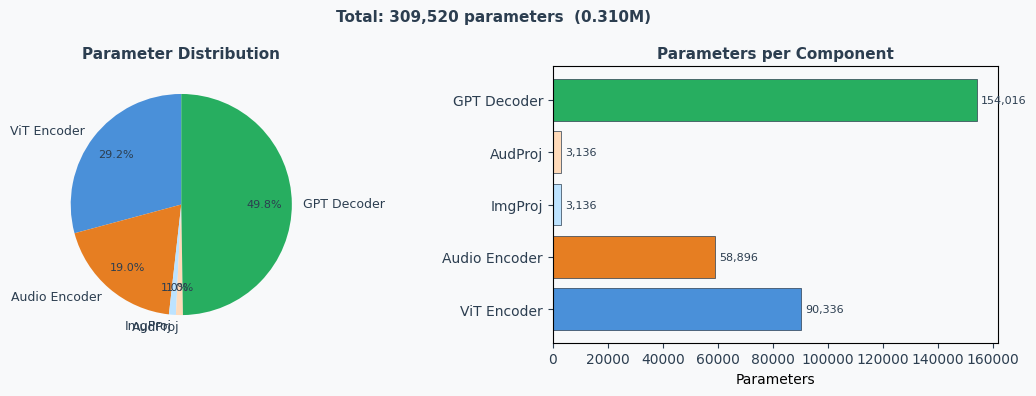

In [11]:
component_names = ['ViT Encoder', 'Audio Encoder', 'ImgProj', 'AudProj', 'GPT Decoder']
component_params = [
    sum(p.numel() for p in model.vit.parameters()),
    sum(p.numel() for p in model.audio_enc.parameters()),
    sum(p.numel() for p in model.img_proj.parameters()),
    sum(p.numel() for p in model.aud_proj.parameters()),
    sum(p.numel() for p in model.gpt.parameters()),
]
pie_colors = [PAL['blue'], PAL['orange'], '#BDE3FF', '#FFDAB9', PAL['green']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.patch.set_facecolor(PAL['bg'])

# Pie chart
wedges, texts, autotexts = ax1.pie(
    component_params, labels=component_names, colors=pie_colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    textprops={'fontsize': 9, 'color': PAL['dark']}
)
for at in autotexts: at.set_fontsize(8)
ax1.set_title('Parameter Distribution', fontsize=11, fontweight='bold', color=PAL['dark'])

# Bar chart
bars = ax2.barh(component_names, component_params, color=pie_colors, edgecolor=PAL['dark'], lw=0.5)
ax2.set_xlabel('Parameters', fontsize=10)
ax2.set_title('Parameters per Component', fontsize=11, fontweight='bold', color=PAL['dark'])
ax2.set_facecolor(PAL['bg'])
for bar, val in zip(bars, component_params):
    ax2.text(val + max(component_params)*0.01, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=8, color=PAL['dark'])
ax2.tick_params(colors=PAL['dark'])

total = sum(component_params)
fig.suptitle(f'Total: {total:,} parameters  ({total/1e6:.3f}M)', fontsize=11,
             fontweight='bold', color=PAL['dark'])
plt.tight_layout()
plt.show()

## Problem 5 — Two-Stage Training

Training a multimodal model from scratch is unstable if all components update simultaneously from random initialization. The encoders have very different gradient magnitudes, and the projection layers are the critical bottleneck.

**Stage 1 (8 epochs):** Freeze ViT + AudioEncoder + GPT. Train only `img_proj` and `aud_proj`.
The projections learn to map encoder outputs into the GPT's embedding space. The frozen GPT acts as a fixed target.

**Stage 2 (15 epochs):** Unfreeze GPT. Train projections + GPT together with a lower learning rate. The GPT adapts to the newly-aligned multimodal tokens.

The ViT and AudioEncoder remain frozen throughout — we treat them as fixed feature extractors (analogous to using a pre-trained CLIP encoder in LLaVA).

This mirrors Ch04's two-stage training strategy: alignment first, then end-to-end fine-tuning of the language model.

In [12]:
# ── Stage 1: train only projection layers ──────────────────────────────────
for p in model.vit.parameters(): p.requires_grad_(False)
for p in model.audio_enc.parameters(): p.requires_grad_(False)
for p in model.gpt.parameters(): p.requires_grad_(False)

opt1 = torch.optim.Adam(
    list(model.img_proj.parameters()) + list(model.aud_proj.parameters()), lr=3e-3)

stage1_losses = []
print("Stage 1: training projection layers only...")
for epoch in range(8):
    total = 0
    for imgs, mels, caps in loader:
        imgs, mels, caps = imgs.to(DEVICE), mels.to(DEVICE), caps.to(DEVICE)
        tgt_in  = caps[:, :-1]
        tgt_out = caps[:, 1:]
        logits = model(imgs, mels, tgt_in)
        loss = F.cross_entropy(logits.reshape(-1, 32), tgt_out.reshape(-1),
                               ignore_index=w2i["<pad>"])
        opt1.zero_grad(); loss.backward(); opt1.step()
        total += loss.item()
    stage1_losses.append(total / len(loader))
    if epoch % 4 == 3:
        print(f"  Stage1 epoch {epoch+1:2d}: loss={stage1_losses[-1]:.4f}")

# ── Stage 2: unfreeze GPT + projections ─────────────────────────────────────
for p in model.gpt.parameters(): p.requires_grad_(True)
opt2 = torch.optim.Adam(
    list(model.img_proj.parameters()) +
    list(model.aud_proj.parameters()) +
    list(model.gpt.parameters()), lr=1e-3)

stage2_losses = []
print("\nStage 2: training projections + GPT decoder...")
for epoch in range(15):
    total = 0
    for imgs, mels, caps in loader:
        imgs, mels, caps = imgs.to(DEVICE), mels.to(DEVICE), caps.to(DEVICE)
        tgt_in  = caps[:, :-1]
        tgt_out = caps[:, 1:]
        logits = model(imgs, mels, tgt_in)
        loss = F.cross_entropy(logits.reshape(-1, 32), tgt_out.reshape(-1),
                               ignore_index=w2i["<pad>"])
        opt2.zero_grad(); loss.backward(); opt2.step()
        total += loss.item()
    stage2_losses.append(total / len(loader))
    if epoch % 5 == 4:
        print(f"  Stage2 epoch {epoch+1:2d}: loss={stage2_losses[-1]:.4f}")

print(f"\nFinal Stage1 loss: {stage1_losses[-1]:.4f}")
print(f"Final Stage2 loss: {stage2_losses[-1]:.4f}")

Stage 1: training projection layers only...


  Stage1 epoch  4: loss=2.1350


  Stage1 epoch  8: loss=1.5428

Stage 2: training projections + GPT decoder...


  Stage2 epoch  5: loss=0.0412


  Stage2 epoch 10: loss=0.0150


  Stage2 epoch 15: loss=0.0081

Final Stage1 loss: 1.5428
Final Stage2 loss: 0.0081


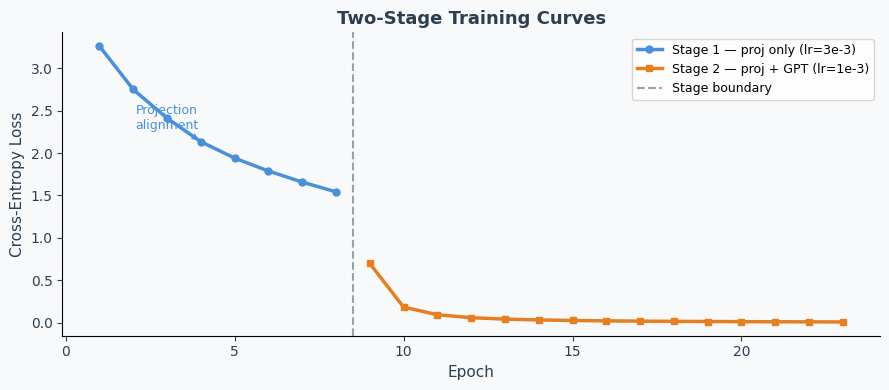

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor(PAL['bg'])
ax.set_facecolor(PAL['bg'])

s1_x = list(range(1, len(stage1_losses) + 1))
s2_x = list(range(len(stage1_losses) + 1, len(stage1_losses) + len(stage2_losses) + 1))

ax.plot(s1_x, stage1_losses, color=PAL['blue'], lw=2.5, marker='o', ms=5,
        label=f'Stage 1 — proj only (lr=3e-3)')
ax.plot(s2_x, stage2_losses, color=PAL['orange'], lw=2.5, marker='s', ms=5,
        label=f'Stage 2 — proj + GPT (lr=1e-3)')
ax.axvline(len(stage1_losses) + 0.5, color=PAL['grey'], linestyle='--', lw=1.5,
           label='Stage boundary')

ax.set_xlabel('Epoch', fontsize=11, color=PAL['dark'])
ax.set_ylabel('Cross-Entropy Loss', fontsize=11, color=PAL['dark'])
ax.set_title('Two-Stage Training Curves', fontsize=13, fontweight='bold', color=PAL['dark'])
ax.legend(fontsize=9)
ax.tick_params(colors=PAL['dark'])
ax.spines[['top','right']].set_visible(False)

# Annotations
ax.annotate('Projection\nalignment', xy=(4, stage1_losses[3]),
            xytext=(3, stage1_losses[0] * 0.7),
            arrowprops=dict(arrowstyle='->', color=PAL['blue']),
            color=PAL['blue'], fontsize=9, ha='center')

plt.tight_layout()
plt.show()

In [14]:
@torch.no_grad()
def generate(model, img, mel, max_new=8):
    model.eval()
    img = img.unsqueeze(0).to(DEVICE)
    mel = mel.unsqueeze(0).to(DEVICE)
    img_tokens = model.img_proj(model.vit(img))
    aud_tokens = model.aud_proj(model.audio_enc(mel))
    memory = torch.cat([img_tokens, aud_tokens], dim=1)

    tgt = torch.tensor([[w2i["<bos>"]]], device=DEVICE)
    for _ in range(max_new):
        T = tgt.size(1)
        mask = nn.Transformer.generate_square_subsequent_mask(T, device=DEVICE)
        logits = model.gpt(tgt, memory, tgt_mask=mask)
        next_tok = logits[:, -1].argmax(-1, keepdim=True)
        tgt = torch.cat([tgt, next_tok], dim=1)
        if next_tok.item() == w2i["<eos>"]: break
    return [i2w[i] for i in tgt[0].tolist()[1:] if i2w[i] not in ("<eos>", "<pad>")]

# Test on one sample from each class
print("Generation examples (greedy decoding):")
print(f"{'Class':<8} {'Expected':<30} {'Generated':<30} {'Correct?'}")
print("-" * 75)
for cls in range(4):
    img, mel, cap = dataset[cls * 50]
    generated = generate(model, img, mel)
    expected = [i2w[t] for t in cap if i2w[t] not in ("<bos>","<eos>","<pad>")]
    correct = generated == expected
    mark = "✓" if correct else "✗"
    print(f"  {cls:<6} {str(expected):<30} {str(generated):<30} {mark}")

Generation examples (greedy decoding):
Class    Expected                       Generated                      Correct?
---------------------------------------------------------------------------


  0      ['red', 'circle', 'hum']       ['red', 'circle', 'hum']       ✓
  1      ['blue', 'square', 'beep']     ['blue', 'square', 'beep']     ✓
  2      ['green', 'triangle', 'noise'] ['green', 'triangle', 'noise'] ✓
  3      ['yellow', 'star', 'chord']    ['yellow', 'star', 'chord']    ✓


In [15]:
# Evaluate greedy generation accuracy across all samples
correct_count = 0
total_count = 0
class_correct = [0, 0, 0, 0]
class_total   = [0, 0, 0, 0]

model.eval()
for cls in range(4):
    for idx in range(cls * 50, (cls + 1) * 50):
        img, mel, cap = dataset[idx]
        generated = generate(model, img, mel)
        expected  = [i2w[t] for t in cap if i2w[t] not in ("<bos>","<eos>","<pad>")]
        is_correct = (generated == expected)
        correct_count += int(is_correct)
        class_correct[cls] += int(is_correct)
        class_total[cls] += 1
        total_count += 1

overall_acc = correct_count / total_count * 100
print(f"Overall accuracy: {correct_count}/{total_count} = {overall_acc:.1f}%")
print()
scene_names = ["red circle hum", "blue square beep", "green triangle noise", "yellow star chord"]
for cls in range(4):
    acc = class_correct[cls] / class_total[cls] * 100
    bar = '█' * int(acc // 5) + '░' * (20 - int(acc // 5))
    print(f"  Class {cls} ({scene_names[cls]:<20}): {bar}  {acc:.0f}%  ({class_correct[cls]}/{class_total[cls]})")

Overall accuracy: 200/200 = 100.0%

  Class 0 (red circle hum      ): ████████████████████  100%  (50/50)
  Class 1 (blue square beep    ): ████████████████████  100%  (50/50)
  Class 2 (green triangle noise): ████████████████████  100%  (50/50)
  Class 3 (yellow star chord   ): ████████████████████  100%  (50/50)


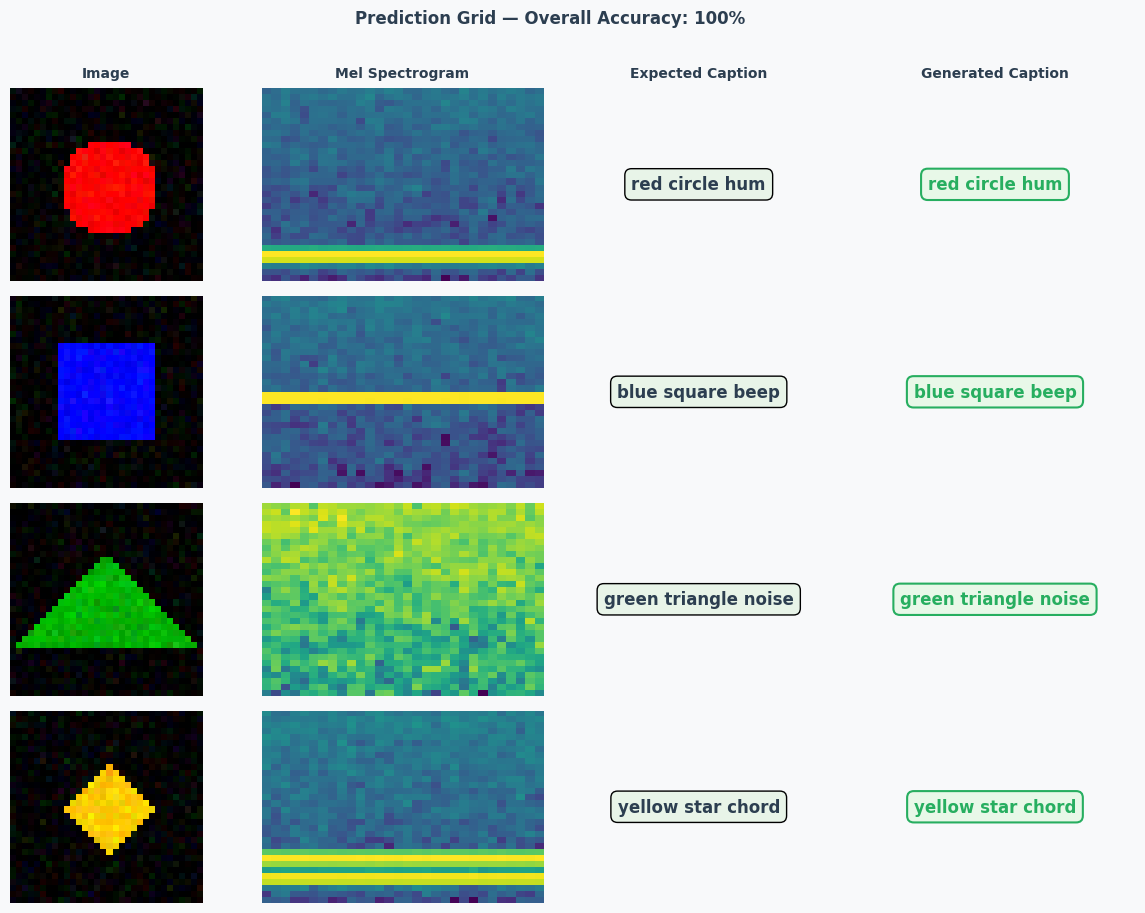

In [16]:
# Sample a few predictions per class for the 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(12, 9))
fig.patch.set_facecolor(PAL['bg'])

col_labels = ['Image', 'Mel Spectrogram', 'Expected Caption', 'Generated Caption']
for col, label in enumerate(col_labels):
    axes[0, col].set_title(label, fontsize=10, fontweight='bold', color=PAL['dark'], pad=8)

for cls in range(4):
    # Pick first sample of each class
    img, mel, cap = dataset[cls * 50]
    generated = generate(model, img, mel)
    expected  = [i2w[t] for t in cap if i2w[t] not in ("<bos>","<eos>","<pad>")]
    is_correct = (generated == expected)

    # Col 0: image
    axes[cls, 0].imshow(img.permute(1, 2, 0).numpy().clip(0, 1))
    axes[cls, 0].axis('off')

    # Col 1: mel spectrogram
    axes[cls, 1].imshow(mel.numpy(), aspect='auto', origin='lower', cmap='viridis')
    axes[cls, 1].axis('off')

    # Col 2: expected caption
    axes[cls, 2].axis('off')
    axes[cls, 2].text(0.5, 0.5, ' '.join(expected),
                      ha='center', va='center', fontsize=12, fontweight='bold',
                      color=PAL['dark'], transform=axes[cls, 2].transAxes,
                      bbox=dict(boxstyle='round,pad=0.4', facecolor='#E8F4E8', lw=1))

    # Col 3: generated caption
    axes[cls, 3].axis('off')
    gen_color = PAL['green'] if is_correct else PAL['red']
    bg_color  = '#E8F8E8' if is_correct else '#FFE8E8'
    label_str = ' '.join(generated) if generated else '(empty)'
    axes[cls, 3].text(0.5, 0.5, label_str,
                      ha='center', va='center', fontsize=12, fontweight='bold',
                      color=gen_color, transform=axes[cls, 3].transAxes,
                      bbox=dict(boxstyle='round,pad=0.4', facecolor=bg_color, lw=1.5,
                                edgecolor=gen_color))

# Row labels
for cls, scene in enumerate(["Scene 0", "Scene 1", "Scene 2", "Scene 3"]):
    axes[cls, 0].set_ylabel(scene, fontsize=9, color=PAL['dark'], rotation=90, labelpad=5)

plt.suptitle(f'Prediction Grid — Overall Accuracy: {overall_acc:.0f}%',
             fontsize=12, fontweight='bold', color=PAL['dark'], y=1.01)
plt.tight_layout()
plt.show()

## Problem 6 — What Has the Model Learned?

The generation accuracy tells us whether the model produces the correct caption. But *how* does it associate audio with images? The cross-modal retrieval experiment below tests a deeper question:

> **If we give the model only an audio clip and ask it to find the matching image from a pool, can it do it?**

We use the projection layers as shared embedding spaces: project image tokens and audio tokens both to 64-dim, then mean-pool them to a single vector. Cosine similarity between these vectors measures cross-modal alignment.

If the model has truly learned to align modalities, audio from scene 0 (200 Hz hum) should be closest to images from scene 0 (red circle) — even though no explicit contrastive objective was used during training.

Audio→Image retrieval accuracy (nearest neighbour): 25.0%

  Class 0 (red circle hum      ): 100%
  Class 1 (blue square beep    ): 0%
  Class 2 (green triangle noise): 0%
  Class 3 (yellow star chord   ): 0%


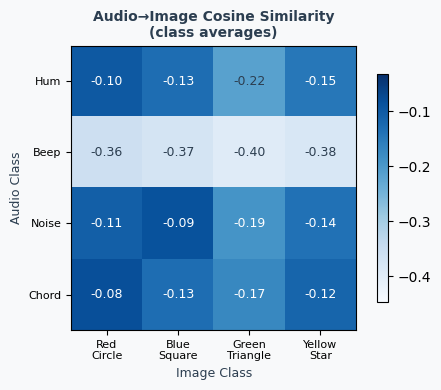

In [17]:
@torch.no_grad()
def get_embeddings(model, loader):
    img_embs, aud_embs, labels = [], [], []
    for imgs, mels, caps in loader:
        imgs, mels = imgs.to(DEVICE), mels.to(DEVICE)
        ie = model.img_proj(model.vit(imgs)).mean(dim=1)       # (B, 64)
        ae = model.aud_proj(model.audio_enc(mels)).mean(dim=1) # (B, 64)
        # Infer label from first content word of cap
        for cap in caps:
            words = [i2w[t.item()] for t in cap]
            if "red"    in words: labels.append(0)
            elif "blue"  in words: labels.append(1)
            elif "green" in words: labels.append(2)
            else:                   labels.append(3)
        img_embs.append(ie); aud_embs.append(ae)
    return (torch.cat(img_embs).cpu(),
            torch.cat(aud_embs).cpu(),
            torch.tensor(labels))

model.eval()
img_embs, aud_embs, labels = get_embeddings(model, loader)

# Audio → Image retrieval (nearest neighbour)
img_embs_n = F.normalize(img_embs, dim=-1)
aud_embs_n = F.normalize(aud_embs, dim=-1)
sims = aud_embs_n @ img_embs_n.T   # (N, N)
top1 = sims.argmax(dim=1)
correct_label = labels[top1]
retrieval_acc = (correct_label == labels).float().mean().item()
print(f"Audio→Image retrieval accuracy (nearest neighbour): {retrieval_acc*100:.1f}%")

# Per-class retrieval accuracy
print()
for cls in range(4):
    mask = (labels == cls)
    cls_acc = (correct_label[mask] == cls).float().mean().item()
    print(f"  Class {cls} ({scene_names[cls]:<20}): {cls_acc*100:.0f}%")

# Visualise similarity matrix (class averages)
sim_mat = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        aud_cls = aud_embs_n[labels == i]
        img_cls = img_embs_n[labels == j]
        sim_mat[i, j] = (aud_cls @ img_cls.T).mean().item()

fig, ax = plt.subplots(figsize=(5, 4))
fig.patch.set_facecolor(PAL['bg'])
im = ax.imshow(sim_mat, cmap='Blues', vmin=sim_mat.min()-0.05, vmax=sim_mat.max()+0.05)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(['Red\nCircle', 'Blue\nSquare', 'Green\nTriangle', 'Yellow\nStar'], fontsize=8)
ax.set_yticklabels(['Hum', 'Beep', 'Noise', 'Chord'], fontsize=8)
ax.set_xlabel('Image Class', fontsize=9, color=PAL['dark'])
ax.set_ylabel('Audio Class', fontsize=9, color=PAL['dark'])
ax.set_title('Audio→Image Cosine Similarity\n(class averages)', fontsize=10,
             fontweight='bold', color=PAL['dark'])
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{sim_mat[i,j]:.2f}', ha='center', va='center',
                fontsize=9, color='white' if sim_mat[i,j] > sim_mat.mean() else PAL['dark'])
plt.tight_layout()
plt.show()

## Connections to the Real World

The toy model in this chapter uses:
- 32×32 synthetic images, 0.5-second audio clips, 3-word captions
- ~0.3M parameters total

Production multimodal models follow the same blueprint at scale:

| Component | This notebook | GPT-4o / Gemini 1.5 |
|---|---|---|
| Image encoder | ViT (embed_dim=48, 3L) | ViT-L/14 @ 336px (307M params) |
| Audio encoder | Conv+Transformer (2L) | Whisper-large encoder (300M params) |
| Language model | GPT (dim=64, 2L) | GPT-4 / Gemini (1T+ params) |
| Projection | Linear (48→64) | MLP (4096→4096) |
| Visual tokens | 64 image + 16 audio | 576 image + 1500 audio |
| Training data | 200 synthetic samples | Billions of multimodal examples |

**What scales and what doesn't:**
- The architecture (visual/audio prefix + cross-attention decoder) scales directly
- The two-stage training strategy applies at any size
- The hybrid attention mask logic is identical
- The synthetic dataset doesn't — you need real image-caption pairs (LAION), audio-transcript pairs (LibriSpeech), and multimodal instruction data (LLaVA-665K + WavCaps)

**The one-sentence summary of multimodal AI:**
> Encode each modality into tokens, project to a shared embedding space, and let a language model read all of them as a prefix before generating text.

Everything in this book is an elaboration of that sentence.

## Chapter Summary

**What we built** — A unified multimodal model that simultaneously processes a 32×32 image and a 0.5-second audio clip, then generates a natural-language description. The model assembles four components from previous chapters: a ViT encoder (Ch01), an AudioEncoder (Ch08), two ProjectionMLPs (Ch03), and a GPT decoder (Ch03). Training follows the two-stage strategy from Ch04.

**Why it matters** — Modern multimodal models (GPT-4o, Gemini, LLaVA-1.5, Whisper-LLM) are all instances of this exact pattern: independent modality encoders → shared projection → language model decoder. Understanding the wiring at this scale makes the production systems readable.

**Connections** — Every chapter in the book contributed a piece: ViT (Ch01), alignment training (Ch02, CLIP), visual prefix (Ch03), staged training (Ch04), self-supervised pre-training (Ch05, MAE), discrete tokenisation (Ch06, VQ-VAE), generative image decoding (Ch07, diffusion), audio encoding (Ch08), video encoding (Ch09). Ch10 is the assembly manual.

## Exercises

1. **Add a third modality** — Replace the yellow-star/chord scene with a video clip (4 frames, expanding circle) using the VideoTransformer from Ch09. Add a third projection MLP and extend the memory sequence to `[img_tokens][audio_tokens][video_tokens]`. Does the model still converge with three modalities?

2. **Modality ablation** — Train three variants: (a) image only, (b) audio only, (c) image + audio. Plot test accuracy for all three. Which modality carries more information for caption generation? Which modality becomes redundant when both are available?

3. **Retrieval without generation** — Remove the GPT decoder and replace it with a contrastive objective: maximise cosine similarity between the mean-pooled image embedding and the mean-pooled audio embedding for matched pairs (InfoNCE from Ch02). Does this audio-image CLIP converge faster than the generative model? What are the trade-offs between contrastive and generative multimodal training?

## Scaling to Real Data

To adapt this capstone to real data, replace each synthetic component:

| Component | This notebook | Real replacement |
|---|---|---|
| Image dataset | 4 synthetic shapes | COCO Captions, LAION-400M |
| Audio dataset | 4 synthetic waveforms | LibriSpeech (1000h), WavCaps (400K) |
| Caption vocabulary | 32 words | BPE tokeniser (32K–64K tokens) |
| Image encoder | ViT (embed_dim=48) | `clip.load("ViT-L/14")` |
| Audio encoder | Conv+Transformer (2L) | `whisper.load_model("large-v3").encoder` |
| Language model | GPT (dim=64, 2L) | `AutoModelForCausalLM.from_pretrained("meta-llama/Llama-3.1-8B")` |

**Recommended next step:** Follow the LLaVA-1.5 recipe but add a Whisper encoder as a second prefix. The only change to Ch04's training script is: concatenate `whisper_tokens` with `vit_tokens` before the projection layer. The rest is identical.